In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent.parent   # notebooks/joint/ → project root
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED   = PROJECT_ROOT / "data" / "processed"
MATCHED_DIR = PROCESSED / "matched"

In [3]:
sephora_labels = pd.read_csv(PROCESSED / "Sephora"/ "sephora_cluster_labels.csv",
                              dtype={"product_id": str, "bv_product_id": str})
ulta_labels    = pd.read_csv(PROCESSED /"Ulta"/ "ulta_cluster_labels.csv",
                              dtype={"product_id": str})
matched        = pd.read_csv(MATCHED_DIR / "matched_pairs.csv",
                              dtype={"sephora_product_id": str,
                                     "ulta_product_id": str})

print(f"Sephora labels : {len(sephora_labels):,} products, "
      f"k={sephora_labels['kmeans_weighted'].nunique()}")
print(sephora_labels["kmeans_weighted"].value_counts().sort_index().to_string())

print(f"\nUlta labels    : {len(ulta_labels):,} products, "
      f"k={ulta_labels['kmeans_weighted'].nunique()}")
print(ulta_labels["kmeans_weighted"].value_counts().sort_index().to_string())

print(f"\nMatched pairs  : {len(matched):,}")

Sephora labels : 1,632 products, k=4
kmeans_weighted
0    614
1    500
2    192
3    326

Ulta labels    : 11,227 products, k=3
kmeans_weighted
0    3545
1    2876
2    4806

Matched pairs  : 379


In [4]:
cross = (
    matched
    .merge(
        sephora_labels[["product_id", "kmeans_weighted"]]
            .rename(columns={"product_id": "sephora_product_id",
                              "kmeans_weighted": "sephora_cluster"}),
        on="sephora_product_id", how="inner"
    )
    .merge(
        ulta_labels[["product_id", "kmeans_weighted"]]
            .rename(columns={"product_id": "ulta_product_id",
                              "kmeans_weighted": "ulta_cluster"}),
        on="ulta_product_id", how="inner"
    )
)

n_dropped = len(matched) - len(cross)
print(f"Matched pairs with both cluster assignments: {len(cross):,}")
if n_dropped:
    print(f"  ({n_dropped} dropped — product_id mismatch between "
          f"segmentation CSV and matched_pairs)")

Matched pairs with both cluster assignments: 379


In [5]:
SEPHORA_LABELS = {
    0: "C0 · High-Volume Mainstream",       # 614 products, rating 4.37, 213 rev/mo
    1: "C1 · Quiet Approval",               # 500 products, rating 4.60, 87 rev/mo
    2: "C2 · Niche Beloved",                # 192 products, rating 4.63, 18 rev/mo
    3: "C3 · Disappointed & Vocal",         # 326 products, rating 3.78, 17.1% neg
}
ULTA_LABELS = {
    0: "C0 · Underperformers",              # 3,545 products, rating 3.83, 18.6% neg
    1: "C1 · Established Stars",            # 2,876 products, rating 4.55, 38.6 rev/mo
    2: "C2 · Quiet High-Satisfiers",        # 4,806 products, rating 4.65, 6.4 rev/mo
}

# Quality tier for consistency scoring
# high ≥ 4.5 avg rating + ≤ 5% negative;  low = opposite;  mid = in between
SEPHORA_TIER = {0: "mid", 1: "high", 2: "high", 3: "low"}
ULTA_TIER    = {0: "low", 1: "high", 2: "high"}

SEPHORA_COLORS = {0: "#FF9800", 1: "#4CAF50", 2: "#2196F3", 3: "#F44336"}
ULTA_COLORS    = {0: "#EF5350", 1: "#66BB6A", 2: "#42A5F5"}

cross["sephora_tier"] = cross["sephora_cluster"].map(SEPHORA_TIER)
cross["ulta_tier"]    = cross["ulta_cluster"].map(ULTA_TIER)
cross["tier_match"]   = cross["sephora_tier"] == cross["ulta_tier"]

In [6]:
ct_raw = pd.crosstab(cross["sephora_cluster"], cross["ulta_cluster"])
ct_pct = ct_raw.div(ct_raw.sum(axis=1), axis=0) * 100   # row-normalised

s_order = sorted(cross["sephora_cluster"].unique())
u_order = sorted(cross["ulta_cluster"].unique())

print("Cross-tabulation — raw counts (Sephora rows → Ulta cols):")
print(ct_raw.to_string())
print("\nRow-normalised % (what % of each Sephora cluster lands in each Ulta cluster):")
print(ct_pct.round(1).to_string())

consistency_rate = cross["tier_match"].mean()
print(f"\nOverall quality-tier consistency: {consistency_rate:.1%}")
print(f"  {cross['tier_match'].sum():,} of {len(cross):,} matched products "
      f"land in equivalent tier on both platforms")

Cross-tabulation — raw counts (Sephora rows → Ulta cols):
ulta_cluster      0   1   2
sephora_cluster            
0                38  84  55
1                15  35  23
2                 4  13  17
3                39  35  21

Row-normalised % (what % of each Sephora cluster lands in each Ulta cluster):
ulta_cluster        0     1     2
sephora_cluster                  
0                21.5  47.5  31.1
1                20.5  47.9  31.5
2                11.8  38.2  50.0
3                41.1  36.8  22.1

Overall quality-tier consistency: 33.5%
  127 of 379 matched products land in equivalent tier on both platforms


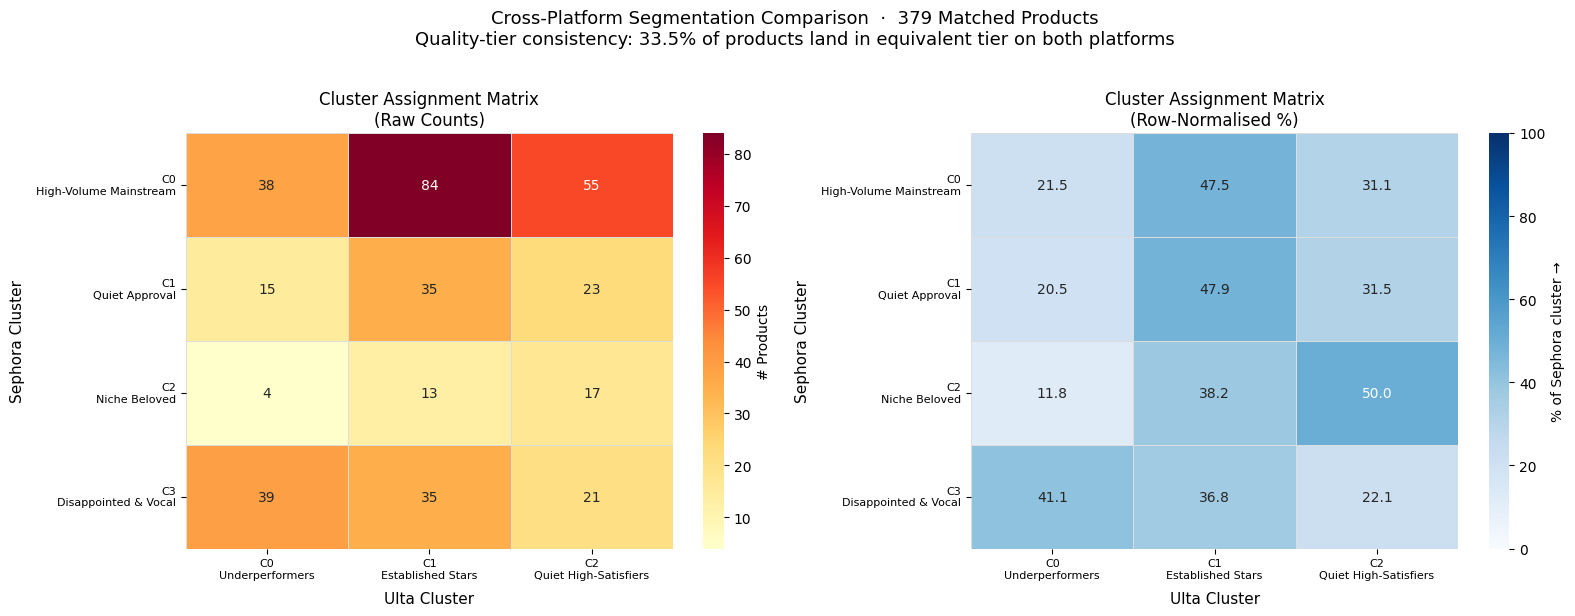

In [7]:
s_tick = [SEPHORA_LABELS[c].replace(" · ", "\n") for c in s_order]
u_tick = [ULTA_LABELS[c].replace(" · ", "\n")    for c in u_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: raw counts
sns.heatmap(
    ct_raw, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=u_tick, yticklabels=s_tick,
    ax=axes[0], linewidths=0.5, linecolor="#ddd",
    cbar_kws={"label": "# Products"},
)
axes[0].set_xlabel("Ulta Cluster", fontsize=11, labelpad=8)
axes[0].set_ylabel("Sephora Cluster", fontsize=11, labelpad=8)
axes[0].set_title("Cluster Assignment Matrix\n(Raw Counts)", fontsize=12)
axes[0].tick_params(axis="both", labelsize=8, rotation=0)

# Right panel: row-normalised %
sns.heatmap(
    ct_pct, annot=True, fmt=".1f", cmap="Blues",
    xticklabels=u_tick, yticklabels=s_tick,
    ax=axes[1], linewidths=0.5, linecolor="#ddd",
    vmin=0, vmax=100, cbar_kws={"label": "% of Sephora cluster →"},
)
axes[1].set_xlabel("Ulta Cluster", fontsize=11, labelpad=8)
axes[1].set_ylabel("Sephora Cluster", fontsize=11, labelpad=8)
axes[1].set_title("Cluster Assignment Matrix\n(Row-Normalised %)", fontsize=12)
axes[1].tick_params(axis="both", labelsize=8, rotation=0)

fig.suptitle(
    f"Cross-Platform Segmentation Comparison  ·  {len(cross):,} Matched Products\n"
    f"Quality-tier consistency: {consistency_rate:.1%} of products land in "
    f"equivalent tier on both platforms",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "2.2_segment_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

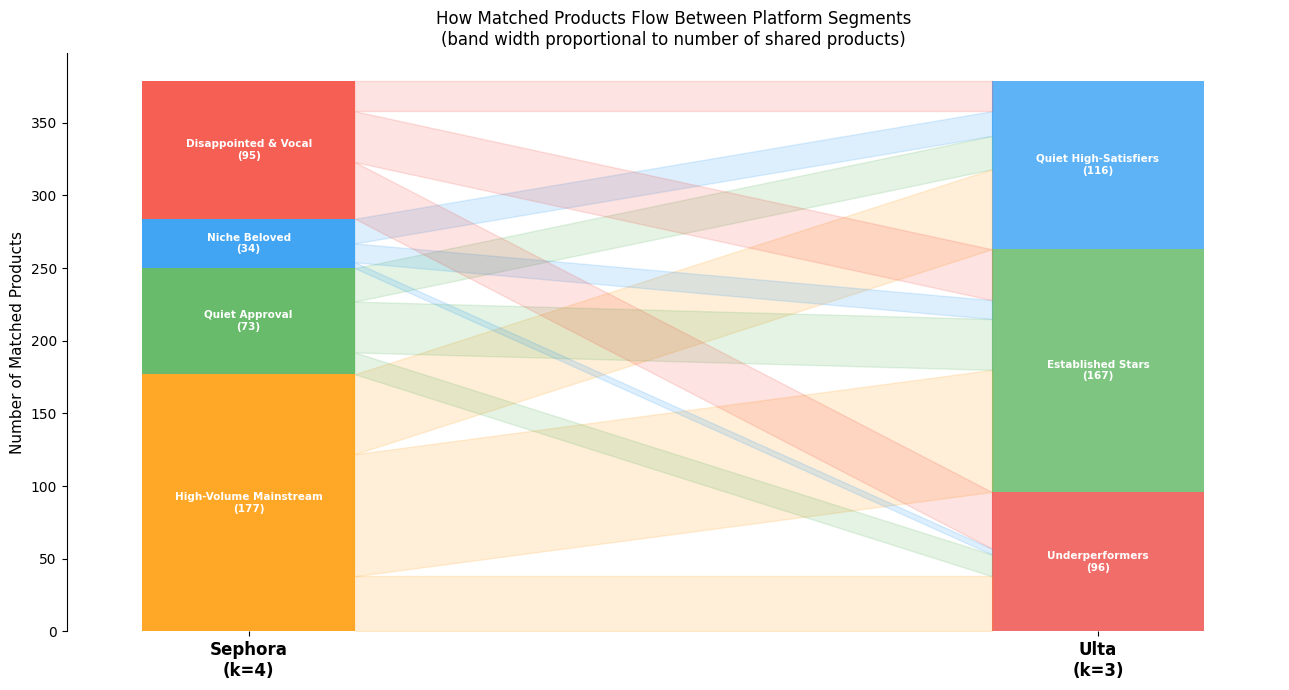

In [8]:
fig, ax = plt.subplots(figsize=(13, 7))

x_s, x_u = 0.3, 1.7
bar_w = 0.35

def draw_bar(ax, x, cluster_order, counts, colors, labels, side="left"):
    bottom = 0
    spans = {}   # cluster → (y_start, y_end)
    for c in cluster_order:
        h = counts.get(c, 0)
        ax.bar(x, h, bar_w, bottom=bottom, color=colors[c], alpha=0.85)
        if h > 3:
            short = labels[c].split(" · ")[1] if " · " in labels[c] else labels[c]
            ax.text(x, bottom + h / 2, f"{short}\n({h})",
                    ha="center", va="center", fontsize=7.5,
                    fontweight="bold", color="white",
                    multialignment="center")
        spans[c] = (bottom, bottom + h)
        bottom += h
    return spans

s_counts = cross["sephora_cluster"].value_counts().to_dict()
u_counts = cross["ulta_cluster"].value_counts().to_dict()

s_spans = draw_bar(ax, x_s, s_order, s_counts, SEPHORA_COLORS, SEPHORA_LABELS)
u_spans = draw_bar(ax, x_u, u_order, u_counts, ULTA_COLORS,    ULTA_LABELS)

# Draw bezier flow bands for each (sephora_cluster, ulta_cluster) pair
s_offsets = {c: s_spans[c][0] for c in s_order}
u_offsets = {c: u_spans[c][0] for c in u_order}

for sc in s_order:
    for uc in u_order:
        n = len(cross[(cross["sephora_cluster"] == sc) &
                      (cross["ulta_cluster"] == uc)])
        if n == 0:
            continue
        y0_bot, y0_top = s_offsets[sc], s_offsets[sc] + n
        y1_bot, y1_top = u_offsets[uc], u_offsets[uc] + n
        s_offsets[sc] += n
        u_offsets[uc] += n
        t = np.linspace(0, 1, 100)
        xs = x_s + bar_w/2 + t * (x_u - bar_w/2 - (x_s + bar_w/2))
        ax.fill_between(
            xs,
            y0_bot  + t * (y1_bot  - y0_bot),
            y0_top  + t * (y1_top  - y0_top),
            color=SEPHORA_COLORS[sc], alpha=0.15,
        )

ax.set_xlim(0, 2)
ax.set_xticks([x_s, x_u])
ax.set_xticklabels(["Sephora\n(k=4)", "Ulta\n(k=3)"], fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Matched Products", fontsize=11)
ax.set_title(
    "How Matched Products Flow Between Platform Segments\n"
    "(band width proportional to number of shared products)",
    fontsize=12,
)
ax.spines[["top", "right", "bottom"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "2.2_segment_flow.png",
            dpi=150, bbox_inches="tight")
plt.show()

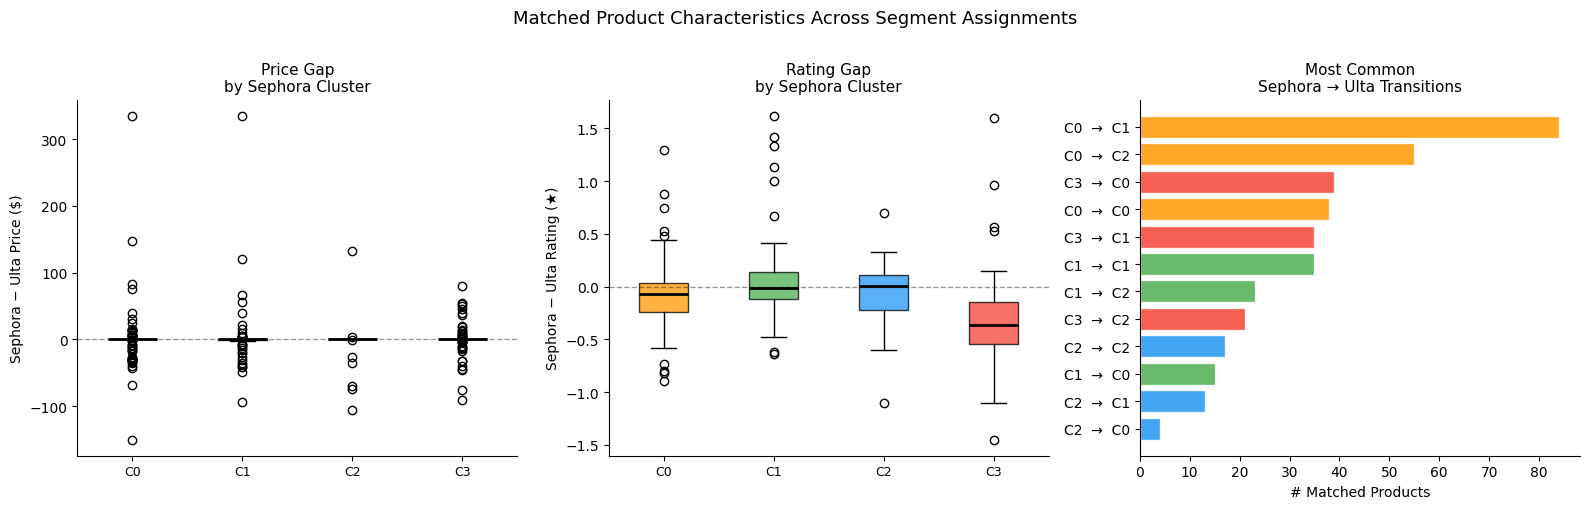

In [10]:
if "price_delta" not in cross.columns:
    cross["price_delta"]  = pd.to_numeric(cross["sephora_price"],  errors="coerce") \
                          - pd.to_numeric(cross["ulta_price"],      errors="coerce")
    cross["rating_delta"] = pd.to_numeric(cross["sephora_rating"], errors="coerce") \
                          - pd.to_numeric(cross["ulta_rating"],     errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: price delta boxplot by Sephora cluster
price_sub = cross.dropna(subset=["price_delta"])
if len(price_sub):
    box_data = [price_sub[price_sub["sephora_cluster"] == c]["price_delta"].values
                for c in s_order]
    bp = axes[0].boxplot(box_data, patch_artist=True,
                         medianprops=dict(color="black", lw=2))
    for patch, c in zip(bp["boxes"], s_order):
        patch.set_facecolor(SEPHORA_COLORS[c])
        patch.set_alpha(0.75)
    axes[0].axhline(0, color="black", lw=1, ls="--", alpha=0.4)
    axes[0].set_xticks(range(1, len(s_order) + 1))
    axes[0].set_xticklabels(
        [SEPHORA_LABELS[c].split(" · ")[0] for c in s_order], fontsize=9
    )
    axes[0].set_ylabel("Sephora − Ulta Price ($)", fontsize=10)
    axes[0].set_title("Price Gap\nby Sephora Cluster", fontsize=11)
    axes[0].spines[["top", "right"]].set_visible(False)

# Panel 2: rating delta boxplot by Sephora cluster
rating_sub = cross.dropna(subset=["rating_delta"])
if len(rating_sub):
    box_data = [rating_sub[rating_sub["sephora_cluster"] == c]["rating_delta"].values
                for c in s_order]
    bp = axes[1].boxplot(box_data, patch_artist=True,
                         medianprops=dict(color="black", lw=2))
    for patch, c in zip(bp["boxes"], s_order):
        patch.set_facecolor(SEPHORA_COLORS[c])
        patch.set_alpha(0.75)
    axes[1].axhline(0, color="black", lw=1, ls="--", alpha=0.4)
    axes[1].set_xticks(range(1, len(s_order) + 1))
    axes[1].set_xticklabels(
        [SEPHORA_LABELS[c].split(" · ")[0] for c in s_order], fontsize=9
    )
    axes[1].set_ylabel("Sephora − Ulta Rating (★)", fontsize=10)
    axes[1].set_title("Rating Gap\nby Sephora Cluster", fontsize=11)
    axes[1].spines[["top", "right"]].set_visible(False)

# Panel 3: top cluster-pair transitions
cross["cluster_pair"] = (
    cross["sephora_cluster"].map(lambda c: SEPHORA_LABELS[c].split(" · ")[0])
    + "  →  "
    + cross["ulta_cluster"].map(lambda c: ULTA_LABELS[c].split(" · ")[0])
)
pair_counts = cross["cluster_pair"].value_counts()
colors_bar = [SEPHORA_COLORS[int(p.split("→")[0].strip()[1])]
              for p in pair_counts.index]
axes[2].barh(pair_counts.index[::-1], pair_counts.values[::-1],
             color=colors_bar[::-1], alpha=0.85, edgecolor="white")
axes[2].set_xlabel("# Matched Products", fontsize=10)
axes[2].set_title("Most Common\nSephora → Ulta Transitions", fontsize=11)
axes[2].spines[["top", "right"]].set_visible(False)

fig.suptitle("Matched Product Characteristics Across Segment Assignments",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "2.2_segment_divergence.png",
            dpi=150, bbox_inches="tight")
plt.show()

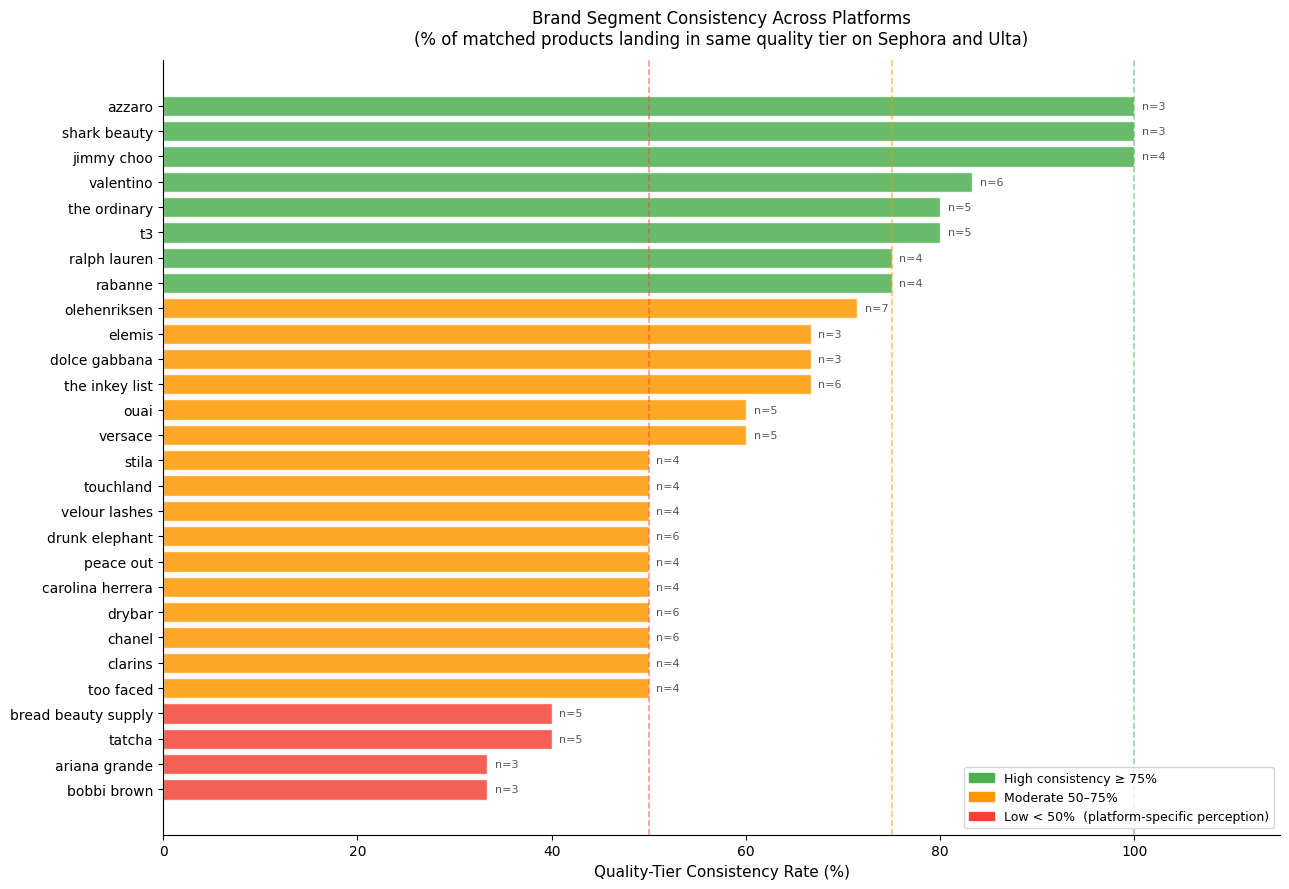

In [11]:
brand_stats = (
    cross
    .groupby("sephora_brand_normalized")
    .agg(
        n          = ("sephora_product_id", "count"),
        consistent = ("tier_match", "sum"),
        s_clusters = ("sephora_cluster",
                      lambda x: sorted(set(SEPHORA_LABELS[c].split(" · ")[1]
                                          for c in x))),
        u_clusters = ("ulta_cluster",
                      lambda x: sorted(set(ULTA_LABELS[c].split(" · ")[1]
                                          for c in x))),
    )
    .assign(consistency_rate=lambda df: df["consistent"] / df["n"])
    .sort_values("n", ascending=False)
    .reset_index()
)

# Chart: brands with ≥ 3 matched products, sorted by consistency rate
plot_df = (brand_stats[brand_stats["n"] >= 3]
           .sort_values("consistency_rate")
           .tail(28))

fig, ax = plt.subplots(figsize=(13, 9))
bar_colors = ["#F44336" if r < 0.5 else
              "#FF9800" if r < 0.75 else
              "#4CAF50"
              for r in plot_df["consistency_rate"]]
bars = ax.barh(plot_df["sephora_brand_normalized"],
               plot_df["consistency_rate"] * 100,
               color=bar_colors, alpha=0.85, edgecolor="white")
for bar, row in zip(bars, plot_df.itertuples()):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f"n={row.n}", va="center", fontsize=8, color="#555")

for xval, color, lbl in [(50, "#F44336", "50%"),
                          (75, "#FF9800", "75%"),
                          (100, "#4CAF50", "100%")]:
    ax.axvline(xval, color=color, lw=1.2, ls="--", alpha=0.55, label=lbl)

ax.set_xlabel("Quality-Tier Consistency Rate (%)", fontsize=11)
ax.set_title(
    "Brand Segment Consistency Across Platforms\n"
    "(% of matched products landing in same quality tier on Sephora and Ulta)",
    fontsize=12, pad=12,
)
ax.set_xlim(0, 115)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color="#4CAF50", label="High consistency ≥ 75%"),
    mpatches.Patch(color="#FF9800", label="Moderate 50–75%"),
    mpatches.Patch(color="#F44336", label="Low < 50%  (platform-specific perception)"),
], fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "2.2_brand_consistency.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [12]:
print("=" * 65)
print("  2.2  CROSS-PLATFORM SEGMENTATION SUMMARY")
print("=" * 65)

for sc in s_order:
    sub = cross[cross["sephora_cluster"] == sc]
    print(f"\n{SEPHORA_LABELS[sc]}  ({len(sub)} matched products):")
    for uc, cnt in sub["ulta_cluster"].value_counts().sort_index().items():
        pct = cnt / len(sub) * 100
        bar = "█" * int(pct / 5)
        print(f"  → {ULTA_LABELS[uc]:<32} {cnt:>3} ({pct:4.1f}%)  {bar}")

print(f"\nOverall quality-tier consistency : {consistency_rate:.1%}")
print(f"Brands fully consistent  (100%) : "
      f"{(brand_stats.query('n >= 2')['consistency_rate'] == 1.0).sum()}")
print(f"Brands inconsistent      (<50%) : "
      f"{(brand_stats.query('n >= 2')['consistency_rate'] < 0.5).sum()}")

print("\nTop 10 most consistent brands (≥3 matched products):")
top10 = (brand_stats[brand_stats["n"] >= 3]
         .sort_values("consistency_rate", ascending=False)
         .head(10))
for _, row in top10.iterrows():
    print(f"  {row['sephora_brand_normalized']:<35}  "
          f"{row['consistency_rate']:.0%}  (n={row['n']})")

print("\nMost inconsistent brands (≥3 matched products):")
bot5 = (brand_stats[brand_stats["n"] >= 3]
        .sort_values("consistency_rate")
        .head(5))
for _, row in bot5.iterrows():
    print(f"  {row['sephora_brand_normalized']:<35}  "
          f"{row['consistency_rate']:.0%}  (n={row['n']})")


  2.2  CROSS-PLATFORM SEGMENTATION SUMMARY

C0 · High-Volume Mainstream  (177 matched products):
  → C0 · Underperformers              38 (21.5%)  ████
  → C1 · Established Stars            84 (47.5%)  █████████
  → C2 · Quiet High-Satisfiers        55 (31.1%)  ██████

C1 · Quiet Approval  (73 matched products):
  → C0 · Underperformers              15 (20.5%)  ████
  → C1 · Established Stars            35 (47.9%)  █████████
  → C2 · Quiet High-Satisfiers        23 (31.5%)  ██████

C2 · Niche Beloved  (34 matched products):
  → C0 · Underperformers               4 (11.8%)  ██
  → C1 · Established Stars            13 (38.2%)  ███████
  → C2 · Quiet High-Satisfiers        17 (50.0%)  ██████████

C3 · Disappointed & Vocal  (95 matched products):
  → C0 · Underperformers              39 (41.1%)  ████████
  → C1 · Established Stars            35 (36.8%)  ███████
  → C2 · Quiet High-Satisfiers        21 (22.1%)  ████

Overall quality-tier consistency : 33.5%
Brands fully consistent  (100%) :